In [1]:
# Day 18: Model Evaluation and Error Analysis

# Project: Student Performance Prediction System

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Student Performance Prediction System")
print("Day 18: Model Evaluation and Error Analysis")
print("Libraries imported successfully!")


Student Performance Prediction System
Day 18: Model Evaluation and Error Analysis
Libraries imported successfully!


In [2]:
# Step 2: Create Student Performance Dataset

data = {
"Study_Hours": [2, 3, 4, 5, 6, 1, 7, 8, 3, 5, 6, 2, 9, 4, 7],
"Attendance": [60, 70, 75, 80, 85, 50, 90, 95, 65, 78, 88, 55, 98, 72, 92],
"Previous_Marks": [45, 50, 55, 60, 65, 35, 75, 85, 48, 62, 70, 40, 90, 58, 80],
"Final_Marks": [48, 52, 58, 65, 70, 38, 78, 88, 50, 64, 73, 42, 94, 60, 83]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Dataset shape:", df.shape)

df.head()


Dataset created successfully!
Dataset shape: (15, 4)


,Study_Hours,Attendance,Previous_Marks,Final_Marks
0,2,60,45,48
1,3,70,50,52
2,4,75,55,58
3,5,80,60,65
4,6,85,65,70


In [3]:
# Step 3: Separate Features and Target

X = df[["Study_Hours", "Attendance", "Previous_Marks"]]
y = df["Final_Marks"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget column:")
print(y.name)


Features shape: (15, 3)
Target shape: (15,)

Feature columns:
['Study_Hours', 'Attendance', 'Previous_Marks']

Target column:
Final_Marks


In [5]:
# Step 4: Split Dataset using NumPy

np.random.seed(42)

indices = np.random.permutation(len(X))
test_size = 3

test_indices = indices[:test_size]
train_indices = indices[test_size:]

X_array = X.to_numpy(dtype=float)
y_array = y.to_numpy(dtype=float)

X_train = X_array[train_indices]
X_test = X_array[test_indices]

y_train = y_array[train_indices]
y_test = y_array[test_indices]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Data split completed successfully!")


Training samples: 12
Testing samples: 3
Data split completed successfully!


In [6]:
# Step 5: Train Linear Regression Model using NumPy

X_train_with_intercept = np.column_stack([
np.ones(len(X_train)),
X_train
])

coefficients = np.linalg.lstsq(
X_train_with_intercept,
y_train,
rcond=None
)[0]

print("Model trained successfully!")
print("Intercept:", coefficients[0])
print("Feature coefficients:", coefficients[1:])


Model trained successfully!
Intercept: 11.594944171156541
Feature coefficients: [ 2.48246662 -0.00389631  0.67082455]


In [7]:
# Step 6: Predict Student Final Marks

X_test_with_intercept = np.column_stack([
np.ones(len(X_test)),
X_test
])

y_pred = X_test_with_intercept @ coefficients

results = pd.DataFrame({
"Actual_Marks": y_test,
"Predicted_Marks": np.round(y_pred, 2),
"Prediction_Error": np.round(y_test - y_pred, 2)
})

print("Predictions completed successfully!")
results


Predictions completed successfully!


,Actual_Marks,Predicted_Marks,Prediction_Error
0,64.0,65.29,-1.29
1,42.0,43.18,-1.18
2,48.0,46.51,1.49


In [8]:
# Step 7: Evaluate Model Performance

# Mean Absolute Error

mae = np.mean(np.abs(y_test - y_pred))

# Mean Squared Error

mse = np.mean((y_test - y_pred) ** 2)

# Root Mean Squared Error

rmse = np.sqrt(mse)

# R-squared Score

ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else float("nan")

print("MODEL EVALUATION RESULTS")
print("-" * 30)
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


MODEL EVALUATION RESULTS
------------------------------
MAE  : 1.32
MSE  : 1.76
RMSE : 1.33
R² Score: 0.9796


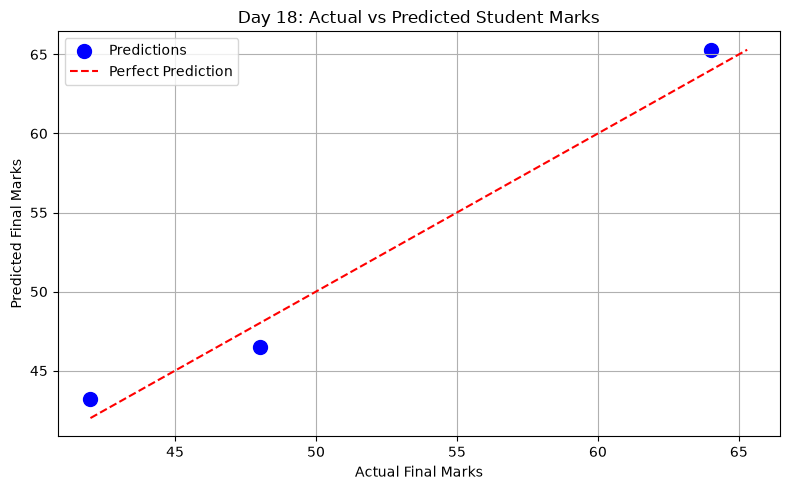

In [9]:
# Step 8: Actual vs Predicted Marks Visualization

plt.figure(figsize=(8, 5))

plt.scatter(
y_test,
y_pred,
color="blue",
s=100,
label="Predictions"
)

min_value = min(np.min(y_test), np.min(y_pred))
max_value = max(np.max(y_test), np.max(y_pred))

plt.plot(
[min_value, max_value],
[min_value, max_value],
color="red",
linestyle="--",
label="Perfect Prediction"
)

plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")
plt.title("Day 18: Actual vs Predicted Student Marks")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
# Step 9: Prediction Error Analysis

results["Absolute_Error"] = np.abs(
results["Actual_Marks"] - results["Predicted_Marks"]
)

print("PREDICTION ERROR ANALYSIS")
print("-" * 35)

print("Average Absolute Error:", round(results["Absolute_Error"].mean(), 2))
print("Maximum Absolute Error:", round(results["Absolute_Error"].max(), 2))
print("Minimum Absolute Error:", round(results["Absolute_Error"].min(), 2))

print("\nDetailed Results:")
results


PREDICTION ERROR ANALYSIS
-----------------------------------
Average Absolute Error: 1.32
Maximum Absolute Error: 1.49
Minimum Absolute Error: 1.18

Detailed Results:


,Actual_Marks,Predicted_Marks,Prediction_Error,Absolute_Error
0,64.0,65.29,-1.29,1.29
1,42.0,43.18,-1.18,1.18
2,48.0,46.51,1.49,1.49


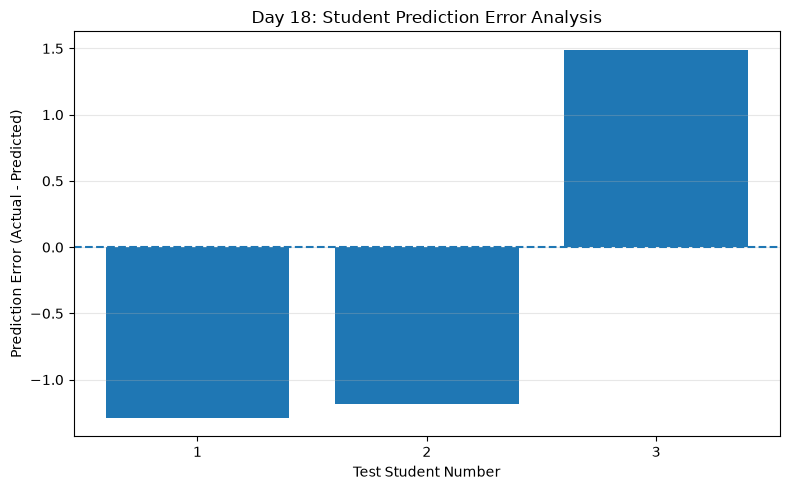

In [11]:
# Step 10: Visualize Prediction Errors

plt.figure(figsize=(8, 5))

plt.bar(
range(1, len(results) + 1),
results["Prediction_Error"]
)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Test Student Number")
plt.ylabel("Prediction Error (Actual - Predicted)")
plt.title("Day 18: Student Prediction Error Analysis")
plt.xticks(range(1, len(results) + 1))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
# Step 11: Model Evaluation Summary

evaluation_report = pd.DataFrame({
"Metric": [
"Mean Absolute Error (MAE)",
"Mean Squared Error (MSE)",
"Root Mean Squared Error (RMSE)",
"R2 Score"
],
"Value": [
round(mae, 2),
round(mse, 2),
round(rmse, 2),
round(r2, 4)
]
})

print("STUDENT PERFORMANCE PREDICTION SYSTEM")
print("DAY 18: MODEL EVALUATION REPORT")
print("=" * 45)

evaluation_report


STUDENT PERFORMANCE PREDICTION SYSTEM
DAY 18: MODEL EVALUATION REPORT


,Metric,Value
0,Mean Absolute Error (MAE),1.3200
1,Mean Squared Error (MSE),1.7600
2,Root Mean Squared Error (RMSE),1.3300
3,R2 Score,0.9796


In [13]:
# Step 12: Save Evaluation Report

report_path = "day18_model_evaluation_report.csv"

evaluation_report.to_csv(report_path, index=False)

print("Evaluation report saved successfully!")
print("File name:", report_path)


Evaluation report saved successfully!
File name: day18_model_evaluation_report.csv


In [14]:
# Step 13: Final Project Summary

print("=" * 50)
print("STUDENT PERFORMANCE PREDICTION SYSTEM")
print("DAY 18: MODEL EVALUATION AND ERROR ANALYSIS")
print("=" * 50)

print("\nDataset Information")
print("Total Students:", len(df))
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

print("\nModel Evaluation")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

print("\nConclusion")
print("The Linear Regression model was evaluated using test data.")
print("Prediction errors were analyzed to understand model performance.")
print("More real student records are needed for reliable evaluation.")

print("\nDay 18 completed successfully!")


STUDENT PERFORMANCE PREDICTION SYSTEM
DAY 18: MODEL EVALUATION AND ERROR ANALYSIS

Dataset Information
Total Students: 15
Training Samples: 12
Testing Samples: 3

Model Evaluation
Mean Absolute Error (MAE): 1.32
Mean Squared Error (MSE): 1.76
Root Mean Squared Error (RMSE): 1.33
R2 Score: 0.9796

Conclusion
The Linear Regression model was evaluated using test data.
Prediction errors were analyzed to understand model performance.
More real student records are needed for reliable evaluation.

Day 18 completed successfully!
